In [44]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, recall_score,  precision_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [45]:

my_dpi = 200
fpath = "NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)
fname = fprop.get_name()
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

In [46]:
origin = load_data('apple_quality')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/kaggle/apple_quality.xlsx
[desc] 이 데이터 세트는 다양한 과일 속성에 대한 정보를 담고 있어 과일의 특성을 파악하는 데 도움이 됩니다. 데이터 세트에는 과일 ID, 크기, 무게, 당도, 아삭함, 과즙량, 숙성도, 산도 및 품질과 같은 세부 정보가 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality)

field        description
-----------  ----------------------------------
A_id         각 과일에 대한 고유 식별자
Size         크기
Weight       무게
Sweetness    단맛 정도
Crunchiness  과일의 아삭한 식감을 나타내는 질감
Juiciness    과일의 과즙 함량 정도
Ripeness     과일이 익은 정도
Acidity      과일의 산도 수준
Quality      과일의 전반적인 품질


===== 데이터 크기 확인 =====
데이터셋 크기: (4000, 9)
열 개수: 9
행 개수: 4000

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   int64  
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunc

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590,good
1,1,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809,good
2,2,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636,bad
3,3,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723,good
4,4,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984,good


📝2단계. 목표 변수 시각화 - “우리가 맞히려는 대상은 어떤 분포를 가지고 있을까?”<br>
Quality의 분포를 막대그래프로 시각화하자.<br>좋은 사과와 그렇지 않은 사과의 비율을 확인하자.<br>이 분포를 보고 정확도 하나만으로 모델을 평가해도 괜찮을지 고민해 보자.

Good/Bad 이진분류<br>
Good 사과는 전체에서 얼마나 차지?<br>
불량사과의 상대적 비중은 얼마?

In [47]:
# Quality 칼럼 전처리
origin['Quality'].value_counts(dropna = False)


Quality
good    2004
bad     1996
Name: count, dtype: int64

In [48]:
origin['Quality'] = (
    origin['Quality']
    .str.strip()      # 앞뒤 공백 제거
    .str.lower()      # 소문자 통일
)


In [49]:
# 다중클래스 분석을 위해서
origin['Quality_binary'] = origin['Quality'].apply(
    lambda x: 'good' if x == 'good' else 'non-good'
)

In [50]:
# 결측치 처리
origin['Quality_binary'].isna().sum()

np.int64(0)

In [51]:
dif_viz = origin.dropna(subset=['Quality_binary'])

In [52]:
# 중복 데이터 점검
dif_viz.duplicated().sum()

np.int64(0)

In [53]:
# 중복 데이터 없앰
dif_viz = dif_viz.drop_duplicates()

In [54]:
count_df = dif_viz['Quality_binary'].value_counts().reset_index()
count_df.columns = ['Quality','Count']
count_df

,Quality,Count
0,good,2004
1,non-good,1996


In [55]:
count_df['Percentage'] = (
    count_df['Count']/count_df['Count'].sum() * 100
)

print(count_df)


print(f"완벽한 균형 클래스")
print(f"클래스 간의 비율이 약 50:50으로 의도적 편향 거의 없다")


    Quality  Count  Percentage
0      good   2004        50.1
1  non-good   1996        49.9
완벽한 균형 클래스
클래스 간의 비율이 약 50:50으로 의도적 편향 거의 없다


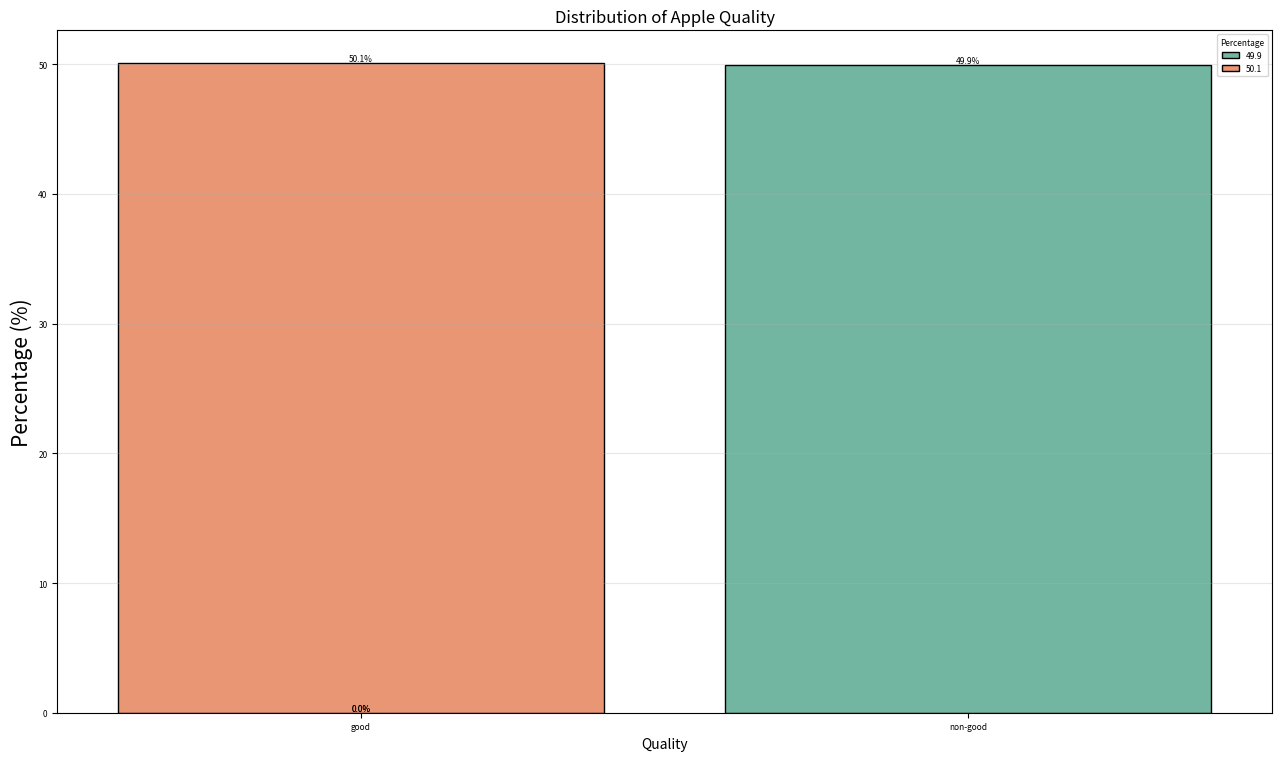

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# figure 설정
width_px = 1280
height_px = 760
my_dpi = 100

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(figsize=figsize, dpi=my_dpi)


sns.barplot(
    data=count_df,
    x='Quality',
    y='Percentage',
    edgecolor='#000000',
    ax=ax,
    hue='Percentage',
    palette='Set2'
)

ax.set_title("Distribution of Apple Quality", fontsize=12)
ax.set_xlabel("Quality", fontsize=10)
ax.set_ylabel("Percentage (%)", fontsize=15)

# 수치 표시
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f"{p.get_height():.1f}%",
        ha='center',
        va='bottom'
    )

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


미션3

In [57]:
na_sum = origin[['Size','Weight','Sweetness','Juiciness','Ripeness','Acidity']].isna().sum()
print(na_sum)
print(f"연속형 변수의 결측치는 모두 0")

Size         0
Weight       0
Sweetness    0
Juiciness    0
Ripeness     0
Acidity      0
dtype: int64
연속형 변수의 결측치는 모두 0


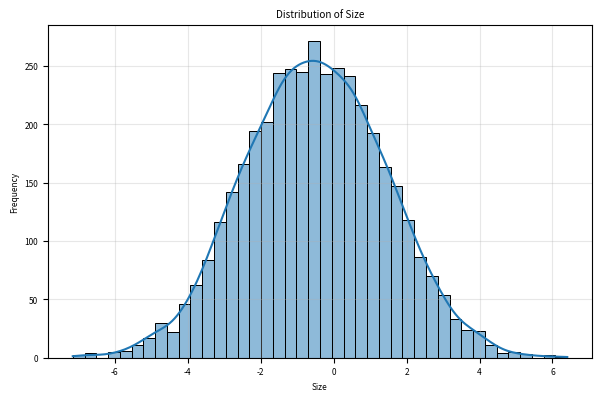

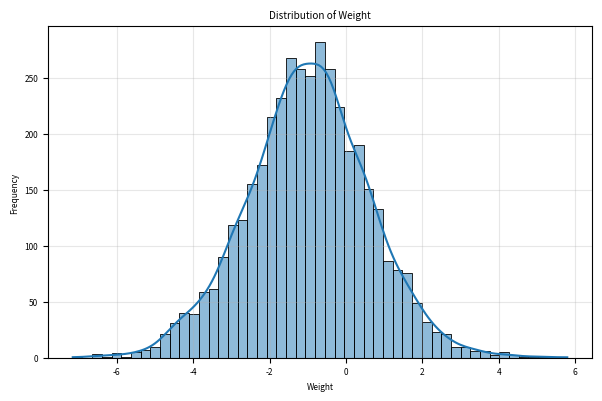

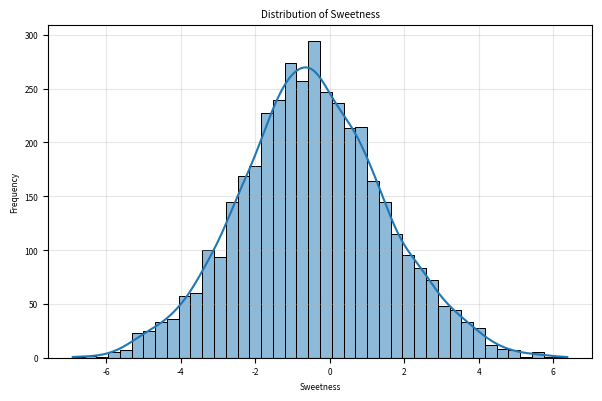

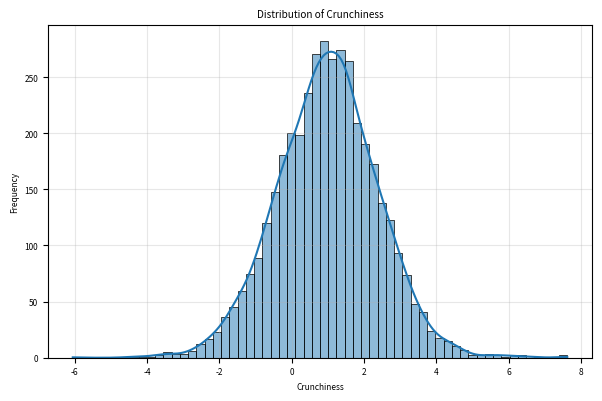

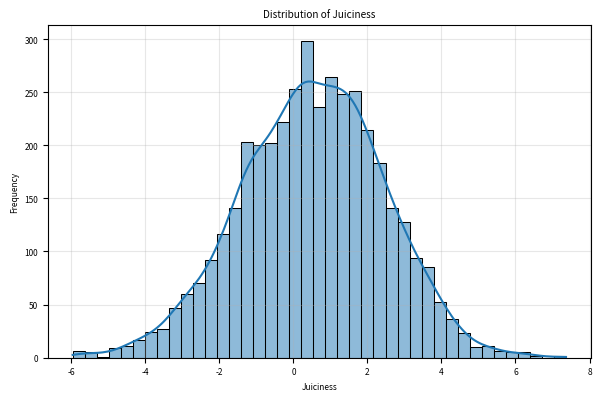

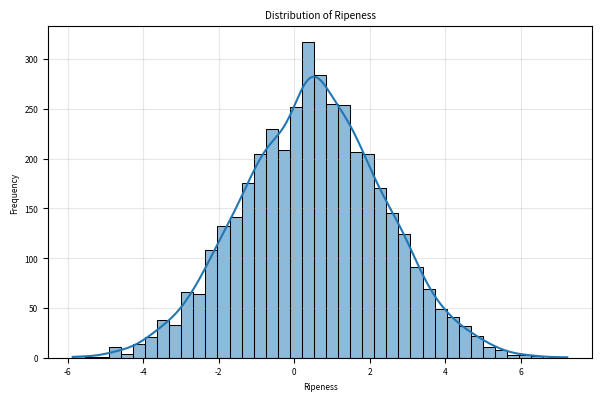

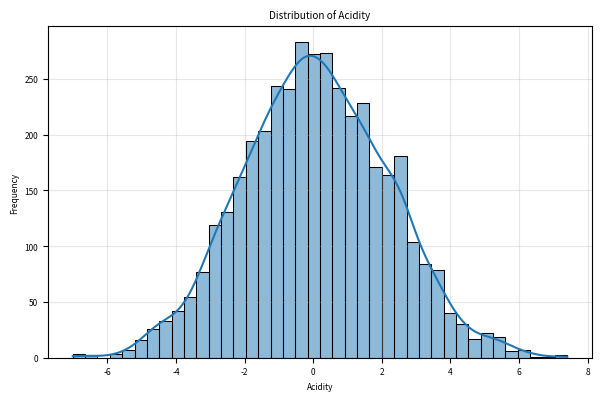

In [58]:
import seaborn as sb
import matplotlib.pyplot as plt
numeric_cols =['Size','Weight','Sweetness','Crunchiness','Juiciness','Ripeness','Acidity']
for col in  numeric_cols:
    plt.figure(figsize=(6,4))


    sb.histplot(data = origin, x=col, kde=True, edgecolor='black')

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()


Sweetness->히스토그램 + KDE 모양이 종모양<br>
           좌우가 비교적 대칭<br>
           꼬리가 왼쪽으로 치우침<br>
           박스플롯에서 Good인 사과가 Sweetness가 더 높다고 나옴<br>
           즉, 품종이 Good인 사과가 Bad보다 더 적게 있다는 것을 알 수 있음<br>
           극단적인 꼬리 없음<br>
           

Crunchiness -> 분포는 매우 뾰족한 종 모양<br>
               중심부에 값이 강하게 집중<br>
               양쪽 꼬리는 존재하지만 급격한 튐은 없음(이상치 아님)<br>
               맛은 어떨까?<br>

Juiciness->    전반적으로 종 모양의 분포를 보이지만, 왼쪽    꼬리가 상대적으로 길어 약한 음의 왜도를 가지는 경향이 관찰됨

Ripeness ->    중심부에 값 하나가 튐<br>
               왼쪽에 이상치같이 보이는 값이 있음 하지만 이상치는 아님<br>


Acidity ->     정규분포 이룸<br>
               오른쪽으로 양의 왜도를 가지려 함



📝미션4 .이변량 EDA - “품질에 따라 무엇이 달라질까?<br>
Quality를 0,1로 나눴을 때 연속형변수의 값은 어떻게 달라질까?

중앙값 차이가 분명한 변수와 분포가 크게 겹치는 변수를 구분하자.<br>분류에 도움이 될 것 같은 변수를 골라 보자

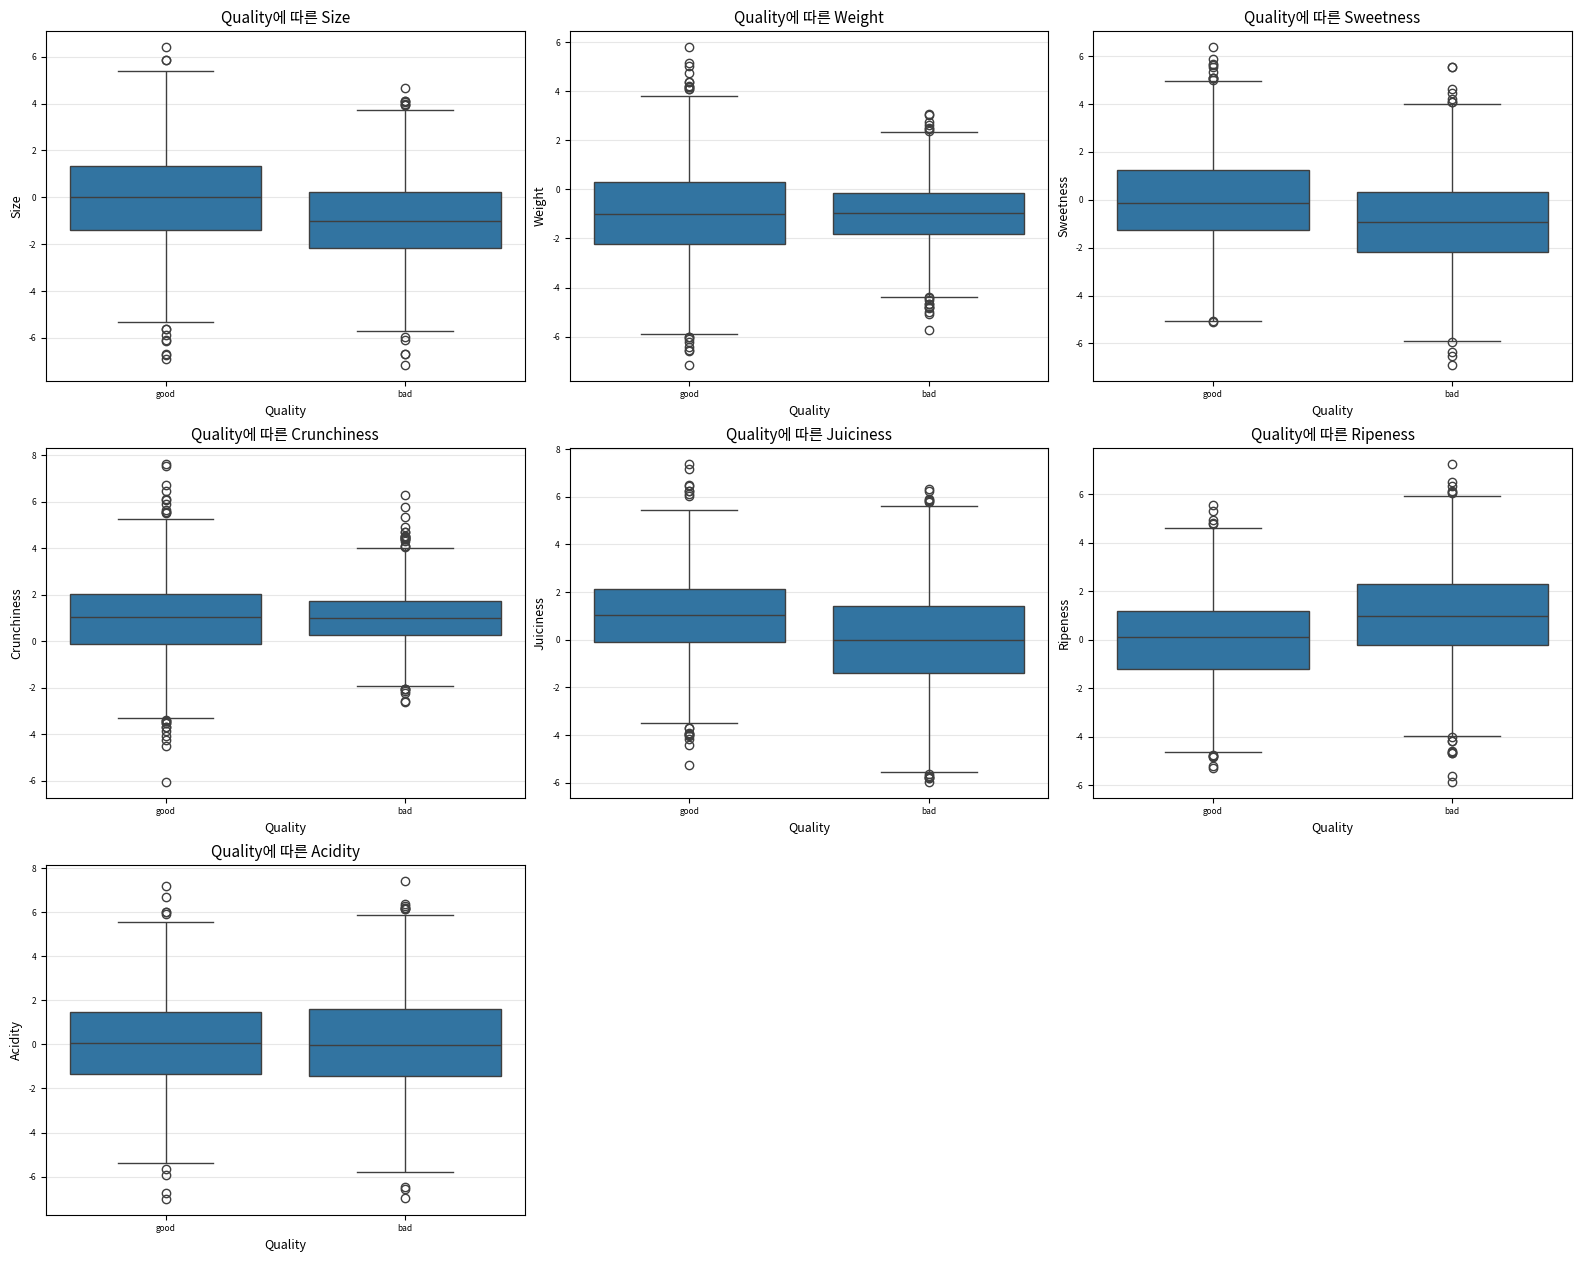

In [59]:
rows, cols = 3, 3

fig, axes = plt.subplots(
    rows, cols,
    figsize=(15.8, 12.6),
    dpi=100,
    
)

for i, col in enumerate(numeric_cols):
    r = i // cols
    c = i % cols

    sb.boxplot(
        data=origin,
        x='Quality',
        y=col,
        ax=axes[r, c]
    )

    axes[r, c].set_title(
        f'Quality에 따른 {col}',
        fontsize=11,
        pad=6
    )

    axes[r, c].set_xlabel('Quality', fontsize=9)
    axes[r, c].set_ylabel(col, fontsize=9)
    axes[r, c].grid(axis='y', alpha=0.3)

# 사용하지 않는 subplot 제거
for j in range(len(numeric_cols), rows * cols):
    r = j // cols
    c = j % cols
    fig.delaxes(axes[r, c])

plt.tight_layout()
plt.show()
plt.close()


양의 상관성이 존재하는 연속형 변수들도 있지만<br>몇가지의 요인들(예:기온, 품종 특성) 때문에 Weight나 Crunchiness에서 예상치 못한 이상치나 분포를 발견할 수 있는 것 같다.
사과의 품질에 영향을 주는 것 같다<br>
또한, 어떠한 변수에서 사분위수 범위가 넓어 중복되는 값이 있을 수도 있다는 생각을 했다.<br>그리하여 중복되는 값을 제거하고 분석을 하는 것도 생각했다. 


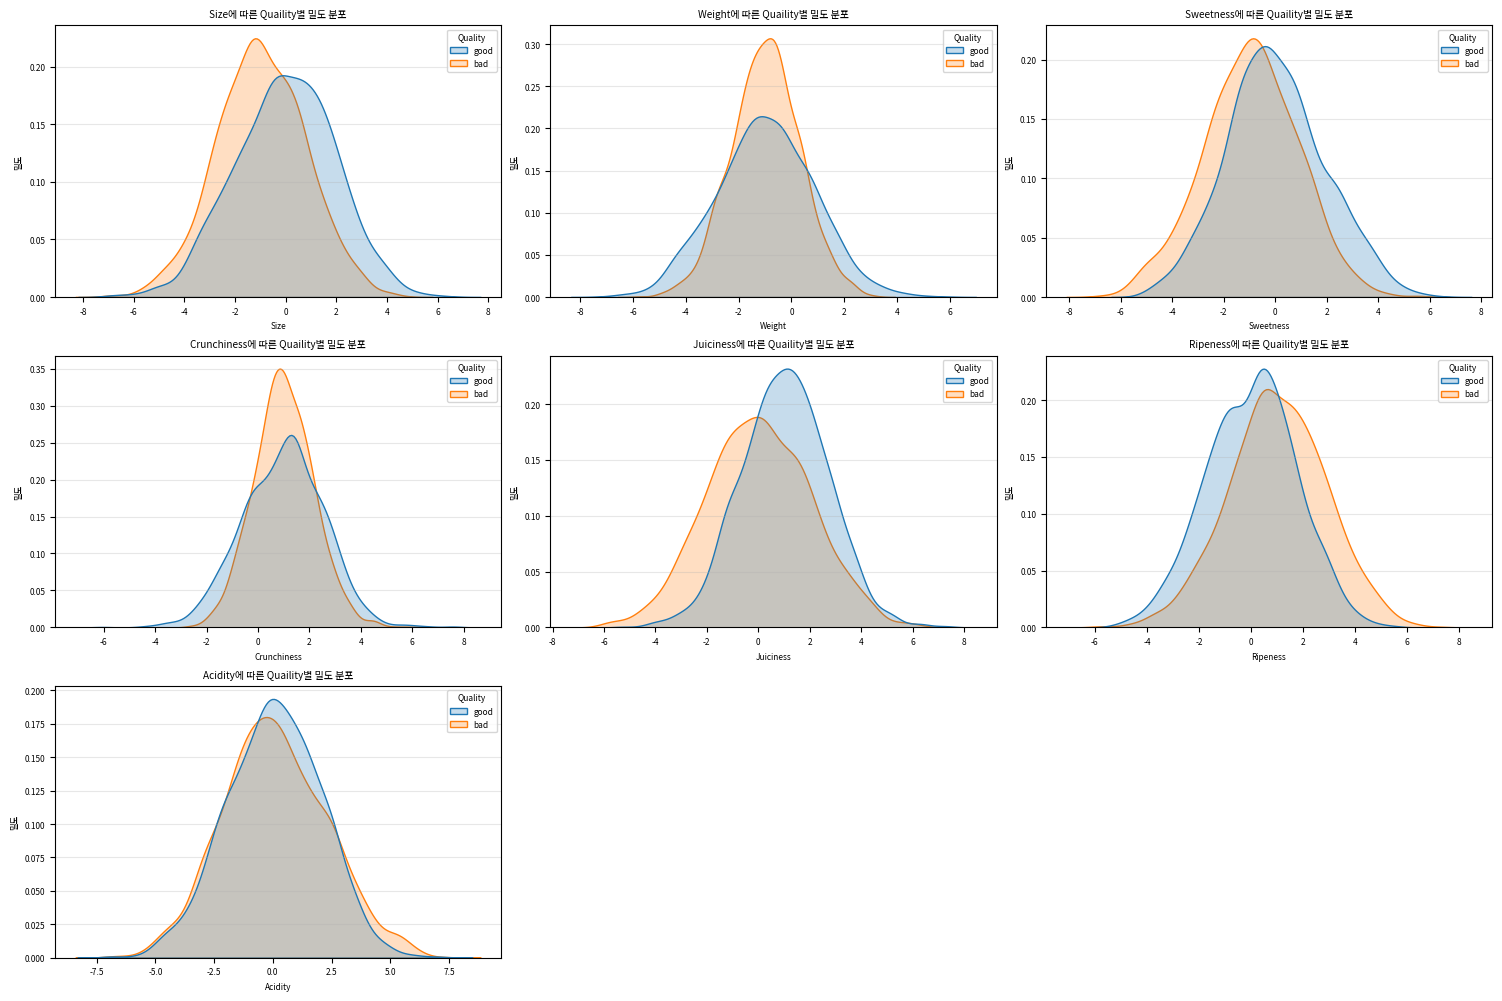

Sweetness가 가장 뚜렷
Juiciness가 그 다음
즉 분포 겹침도가 상대적으로 적어 분류에 기여할 가능성이 높은 변수로 판단
반면, weight,Crunchiness,Acidity는 두 그룹의 분포가 크게 겹쳐 단독 변수로서의 구분력은 제한적으로 보임

이 변수들 사이에 관계가 선형일 것인가 아님 비선형일것인가?



In [60]:
import matplotlib.pyplot as plt
import seaborn as sb
numeric_cols = ['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity']

# 크기 설정
plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols,1):
    plt.subplot(3,3,i)
    sb.kdeplot(data=origin, x=col, hue='Quality', fill=True, common_norm=False)
    plt.title(f'{col}에 따른 Quaility별 밀도 분포')
    plt.xlabel(f'{col}')
    plt.ylabel('밀도')
    plt.grid(True, axis='y', alpha=0.3)

# 서브플롯 간 간격 자동 조절
plt.tight_layout()
plt.show()
print(f"Sweetness가 가장 뚜렷\nJuiciness가 그 다음\n즉 분포 겹침도가 상대적으로 적어 분류에 기여할 가능성이 높은 변수로 판단\n반면, weight,Crunchiness,Acidity는 두 그룹의 분포가 크게 겹쳐 단독 변수로서의 구분력은 제한적으로 보임")
print(f"")
print(f"이 변수들 사이에 관계가 선형일 것인가 아님 비선형일것인가?\n")

📝5단계.변수 간 관계 탐색-"변수들은 서로 독립적일까?"<br>
1.연속형 변수들의 상관계수를 계산하자<br>
2.상관행렬을 히트맵을 시각화하자<br>
3.상관이 높은 변수들을 동시에 사용할 때의 문제점을 고민해 보자.

연속형 변수 간 관계유형<br>
🔹이 변수들 사이의 관계가 선형일 것 같은가?<br>
🔹비선형일 가능성이 큰가?<br>
<br>


In [61]:
# 히트맵
numeric_cols = [
    'Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity'
]

corr_df = origin[numeric_cols].corr()
print(corr_df)
print(f"\n\n----------결론--------------\n"
      f"상관관계 분석결과, Size는 Juiciness,Ripeness,Acidity와 약한 수준의 상관관게를 보임.\n"
      f"Ripeness간에는 음의 상관관계가 관찰되어, Size가 큰 샘플일수록 Ripeness가 상대적으로 낮은 경향이 나타남.\n"
      f"다만 모든 상관계수의 절댓값이 0.3 미만이므로, 변수 간 관계는 약한 수준에 해당.\n"
      f"따라서, Juiciness,Ripeness,Acidity는 완전히 중복되는 변수라기보다는, 서로 다른 정보를 부분적으로 제공하는 변수로 해석할 수 있음")

                 Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
Size         1.000000 -0.170702  -0.324680     0.169868  -0.018892 -0.134773   
Weight      -0.170702  1.000000  -0.154246    -0.095882  -0.092263 -0.243824   
Sweetness   -0.324680 -0.154246   1.000000    -0.037552   0.095882 -0.273800   
Crunchiness  0.169868 -0.095882  -0.037552     1.000000  -0.259607 -0.201982   
Juiciness   -0.018892 -0.092263   0.095882    -0.259607   1.000000 -0.097144   
Ripeness    -0.134773 -0.243824  -0.273800    -0.201982  -0.097144  1.000000   
Acidity      0.196218  0.016414   0.085999     0.069943   0.248714 -0.202669   

              Acidity  
Size         0.196218  
Weight       0.016414  
Sweetness    0.085999  
Crunchiness  0.069943  
Juiciness    0.248714  
Ripeness    -0.202669  
Acidity      1.000000  


----------결론--------------
상관관계 분석결과, Size는 Juiciness,Ripeness,Acidity와 약한 수준의 상관관게를 보임.
Ripeness간에는 음의 상관관계가 관찰되어, Size가 큰 샘플일수록 Ripeness가 상대적으로 낮은 경향이 나타남.
다만 모든 상

히트맵

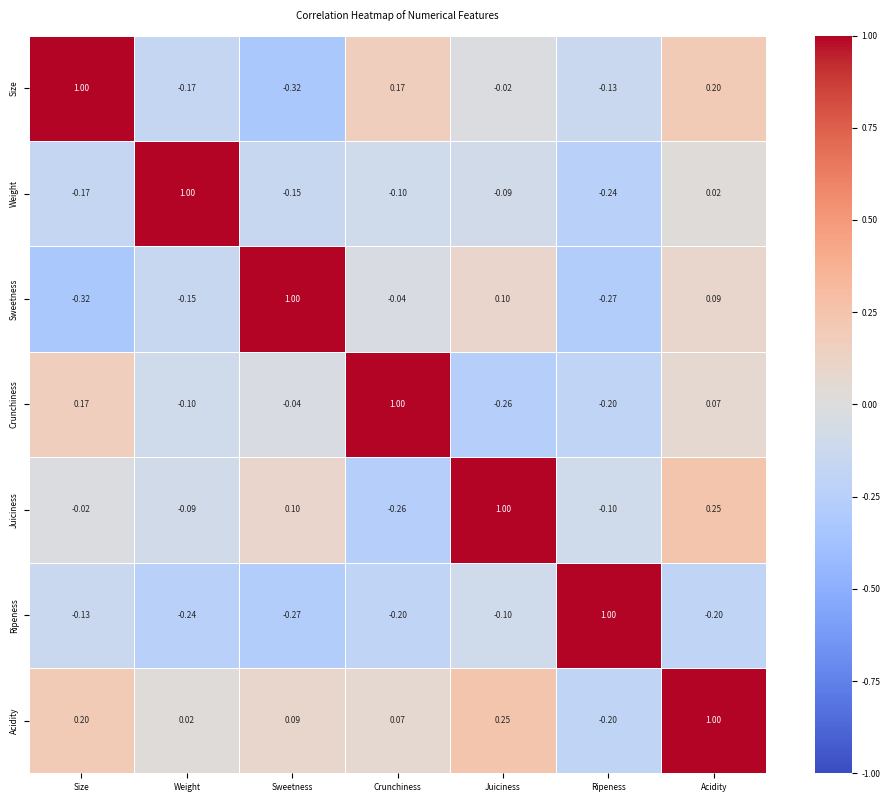

In [62]:
numeric_cols = [
    'Size', 'Weight', 'Sweetness', 'Crunchiness',
    'Juiciness', 'Ripeness', 'Acidity'
]

corr_df = origin[numeric_cols].corr()
corr_df

plt.figure(figsize=(10, 8))

sb.heatmap(
    corr_df,
    annot=True,          # 상관계수 값 표시
    fmt=".2f",           # 소수점 2자리
    cmap="coolwarm",     # 양/음 상관 대비
    vmin=-1,
    vmax=1,
    square=True,         # 셀 정사각형
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", pad=12)
plt.tight_layout()
plt.show()


Sweetness와 Juiciness가 비교적 높은 양의 상관관계를 보임<br>
p-value가 말도 안되게 작은 이유는<br>
--->표본이 큼<br>
--->상관관계의 크기는 0.25 수준으로 중간 이하지만, 표본 수가 크기 때문에 이 관계는 통계적으로 매우 유의<br>



📝6단계.EDA를 바탕으로 한 모델 설계-"그려본 결과를  어떻게 모델로 옮길까?"

지금까지의 EDA 결과를 간단히 요약하자.<br>
사용할 독립변수를 최종 선정하자.<br>
각 변수 선택에 대해 다음 문장을 완성하자.<br>
“이 변수는 EDA 단계에서 ○○한 패턴을 보였기 때문에 품질을 설명하는 데 도움이 될 것으로 판단했다.”

"Juiciness는 EDA 단계에서 단독변수로서 양의 상관관계에에 있는 패턴을 보였기 때문에 품질을 설명하는 데 도움이 될 것으로 판단했다"<br>
"Weight, Crunchiness, Acidity는 Quality와의 상관관계가 매우 약하고 분포 중첩이 커 단독 변수로서의 설명력이 제한적이라고 판단되어 최종모델에서는 제외"

📝7단계. 로지스틱 회귀 모델 적합 - “확률로 말하는 분류기”로지스틱 회귀 모델을 적합하자.회귀계수의 부호와 크기를 확인하자.EDA에서 예상한 방향과 결과가 일치하는지 비교하자"

In [63]:
# Sweetness, Juiciness, Ripeness,Size(보조변수)
features = ['Sweetness', 'Juiciness','Ripeness','Size']

x = origin[features]
y=origin['Quality']



In [76]:
# 이 모델을 어떤 설정으로 학습했는지
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

logit = LogisticRegression()
print(f"이 모델은 StandardScaler로 표준화된 입력을 사용하여,\n"
      f"L2 규제를 가진 기본 로지스틱 회귀 설정에서 학습되었으며,\n"
      f"모든 클래스를 동일한 중요도로 간주하고\n"
      f"확률 0.5를 기준으로 good과 bad를 판단하도록 학습되었다.")
logit.fit(X_scaled, y)

이 모델은 StandardScaler로 표준화된 입력을 사용하여,
L2 규제를 가진 기본 로지스틱 회귀 설정에서 학습되었으며,
모든 클래스를 동일한 중요도로 간주하고
확률 0.5를 기준으로 good과 bad를 판단하도록 학습되었다.


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [65]:
#회귀계수 확인
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': logit.coef_[0]
}).sort_values(by='Coefficient', ascending=False)


print(f"가장 왼쪽에 분포되어있는 연속형 변수 Size의 상관계수가 가장 큼.\n그리고 예상대로 Ripiness의 상관계수가 음의 상관. 역시 많이 익을수록 품종이 bad")
coef_df


가장 왼쪽에 분포되어있는 연속형 변수 Size의 상관계수가 가장 큼.
그리고 예상대로 Ripiness의 상관계수가 음의 상관. 역시 많이 익을수록 품종이 bad


,Feature,Coefficient
3,Size,0.906816
0,Sweetness,0.828015
1,Juiciness,0.623560
2,Ripeness,-0.310128


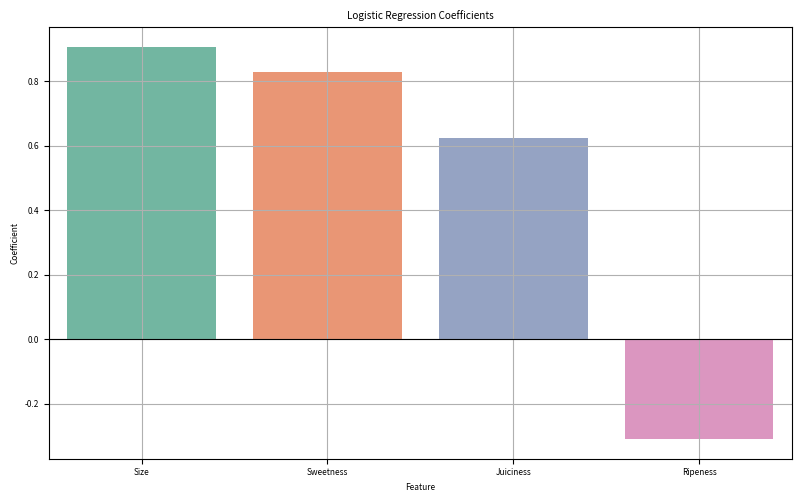

In [66]:

plt.figure(figsize=(8,5))

# 그래프 그리기->seaborn 사용
sb.barplot(data=coef_df, x="Feature", y="Coefficient", palette = "Set2", hue="Feature")


plt.axhline(0, color='black', linewidth=0.8)
plt.title("Logistic Regression Coefficients")
plt.grid()
plt.tight_layout()
plt.show()
plt.close()


📝8단계. 오즈비를 통한 해석 - “숫자를 다시 사람의 언어로”회귀계수를 오즈비로 변환하자.<br>
주요 변수 2~3개를 골라 해석 문장을 작성하자.이 해석이 EDA 결과와 어떻게 연결되는지 설명하자.<br>
📌출제 의도 이 단계의 목적은 계산이 아니라 모델이 말하는 내용을 사람의 언어로 바꾸는 연습이다.

In [67]:
# 회귀계수 추출
coef = logit.coef_[0]

# 오즈비 계산
odds_ratio = np.exp(coef)

# 정리된 DataFrame
or_df = pd.DataFrame({
    "Feature": features,
    "Coefficient (β)": coef,
    "Odds Ratio (e^β)": odds_ratio
}).sort_values("Odds Ratio (e^β)", ascending=False)

or_df

,Feature,Coefficient (β),Odds Ratio (e^β)
3,Size,0.906816,2.476426
0,Sweetness,0.828015,2.288770
1,Juiciness,0.623560,1.865557
2,Ripeness,-0.310128,0.733353


본 로지스틱 회귀 모델은 사과의 크기(Size), 당도(Sweetness), 과즙감(Juiciness)을<br>
품질을 판단하는 주요한 긍정적 요인으로 학습하였으며,<br>
특히 크기와 당도는 평균 대비 1표준편차 증가 시<br>
good일 오즈를 각각 약 2.5배, 2.3배까지 증가시키는 가장 강력한 변수로 나타났다.<br>

반면 숙성도(Ripeness)는 오즈비가 1보다 작은 값으로 추정되어,<br>
숙성도가 과도하게 높아질 경우 오히려 품질이 저하되는 경향을 보였다.<br>
이러한 결과는 EDA에서 관찰된 분포 특성과 일관되며,<br>
본 모델이 인간의 품질 판단 기준을 데이터 기반으로 합리적으로 반영하고 있음을 시사한다.<br>

전반적으로 본 모델은 단순 예측을 넘어,<br>
품질 판단에 영향을 미치는 요인의 방향성과 상대적 중요도를<br>
해석 가능하게 제공하는 설명력 있는 분류 모델이라 할 수 있다.<br>

한 줄로 요약하면<br>
이 모델은 “크고, 달고, 과즙이 많되, 너무 익지는 않은 사과”를
good이라고 판단한다.

📝9단계. 시각화로 보는 모델 성능 - “모델은 어떤 판단을 하고 있을까?”

1️⃣ 혼동행렬(Confusion Matrix) 시각화

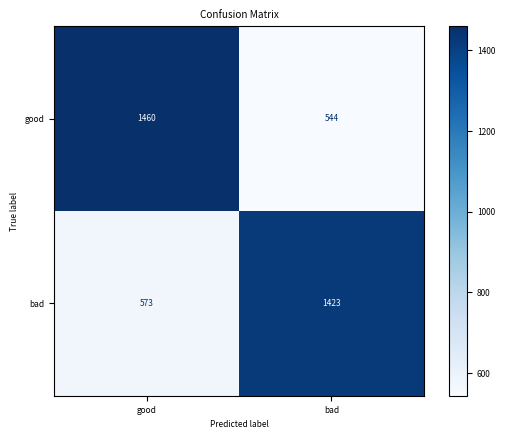

good 중 상당수가 확률 0.4~0.5 구간에 몰려있다.
특히 size는 크지 않지만, Sweetness/Juiciness는 애매
Ripeness는 높은 경우
이런 샘플들은
실제로는 good
하지만, 모델은 보수적으로 bad로 판단


핵심 원인:Ripeness의 음(-) 효과
Ripeness OR ≈ 0.73
Ripeness ↑ → good 오즈 감소
따라서
잘 익었지만(size,sweetness가 평균수준인 good 사과
👉모델이 bad로 밀어버림


왜 FP(573)도 적지 않은가?
핵심 원인: Size / Sweetness의 강한 영향력
Size 큼 & Sweetness 높음
하지만 현실 데이터에서는:
겉보기 스펙은 좋은데 실제 품질은 bad인 사과 존재
내부 손상
과숙 직전
산미 불균형


FP에서 ripeness가 높은 사과가 bad가 아닌 이유
FP로 예측한 이유는, Ripeness가 낮아서가 아니라 Ripeness가 결정적이지 않은 구간에 있기 때문


In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 예측값
y_pred = logit.predict(X_scaled)

# 혼동행렬 계산
cm = confusion_matrix(y, y_pred, labels=["good", "bad"])

# 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["good", "bad"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
print(f"good 중 상당수가 확률 0.4~0.5 구간에 몰려있다.\n"
      f"특히 size는 크지 않지만, Sweetness/Juiciness는 애매\n"
      f"Ripeness는 높은 경우")
print(f"이런 샘플들은\n"
      f"실제로는 good\n"
      f"하지만, 모델은 보수적으로 bad로 판단\n\n")

print(f"핵심 원인:Ripeness의 음(-) 효과\n"
      f"Ripeness OR ≈ 0.73\n"
      f"Ripeness ↑ → good 오즈 감소\n"
      f"따라서\n"
      f"잘 익었지만(size,sweetness가 평균수준인 good 사과\n"
      f"👉모델이 bad로 밀어버림"
      )

print(f"\n\n왜 FP(573)도 적지 않은가?\n"
      f"핵심 원인: Size / Sweetness의 강한 영향력\n"
      f"Size 큼 & Sweetness 높음\n"
      f"하지만 현실 데이터에서는:\n"
      f"겉보기 스펙은 좋은데 실제 품질은 bad인 사과 존재\n"
      f"내부 손상\n과숙 직전\n산미 불균형")

print(f"\n\nFP에서 ripeness가 높은 사과가 bad가 아닌 이유\n"
      f"FP로 예측한 이유는, Ripeness가 낮아서가 아니라 Ripeness가 결정적이지 않은 구간에 있기 때문")


False Positive로 분류된 사과들은 숙성도가 낮아서가 아니라,<br>
숙성도만으로는 품질을 단정할 수 없는 경계 구간에 위치하면서<br>
크기와 당도 같은 외형적 특성이 우수해 모델이 good으로 판단한 사례들이다.

2️⃣ ROC Curve & AUC 계산

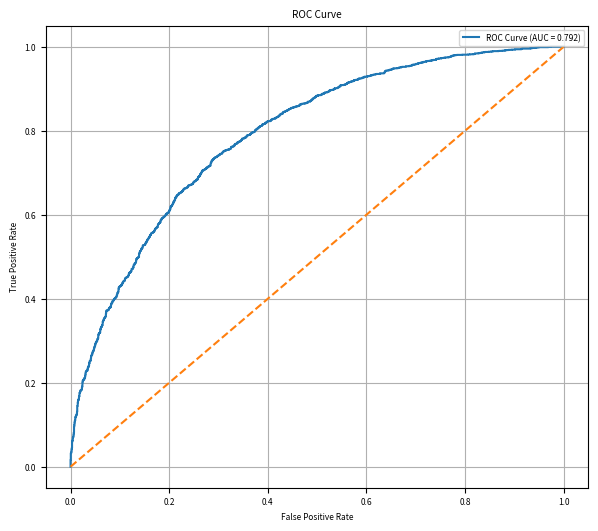

약 0.8수준의 AUC로  안정적인 판별 성능을 확인할 수 있다


In [69]:
from sklearn.metrics import auc
y_prob = logit.predict_proba(X_scaled)[:, 1]  # good 확률

fpr, tpr, thresholds = roc_curve(y, y_prob, pos_label="good")
roc_auc = auc(fpr, tpr)

# 시각화
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()
print(f"약 0.8수준의 AUC로  안정적인 판별 성능을 확인할 수 있다")

📝10단계. 같은 조건, 다른 판단 - “모델은 어디서 갈림길을 만들었을까?”<br>
가상의 사과 두 개를 설정하자.예측 확률이 달라진 이유를 분석하자.<br>
EDA → 회귀계수 → 확률의 흐름으로 설명하자.<br>
📌출제 의도 이 단계는 분석의 마무리 단계로, 모델의 판단을 대신 설명할 수 있는지를 확인하기 위한 문제이다.


사과 A (Ripeness = 중간)<br>
긍정 신호(Size·Sweetness)가 충분<br>
Ripeness 패널티가 약함<br>
👉 최종 점수 > 0.5 → good<br>

사과 B (Ripeness = 조금 높음)<br>
긍정 신호는 동일<br>
Ripeness 패널티가 누적되어 커짐<br>
👉 최종 점수 < 0.5 → bad<br><br>


동일한 크기와 당도를 가진 사과라도,<br>
숙성도가 일정 수준을 넘어설 경우<br>
모델은 품질 저하 가능성을 더 크게 반영하여<br>
bad로 분류하는 경향을 보였다.<br>
이는 EDA에서 관찰된 숙성도 증가에 따른<br>품질 저하 경향과 일관되며,<br>
로지스틱 회귀 계수 및 확률 예측 결과를 통해<br>
해당 판단 경계가 형성되는 지점을 명확히 확인할 수 있었다.<br>
본 분석은 모델의 판단을 단순 예측이 아닌<br>
설명 가능한 의사결정 규칙으로 해석할 수 있음을 보여준다.<br>
